In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "News_Category_Dataset_v3.json"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "rmisra/news-category-dataset",
  file_path,
  pandas_kwargs={'lines': True}
)

Using Colab cache for faster access to the 'news-category-dataset' dataset.


In [ ]:

df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
# Shape of the dataset
print("Dataset Shape:", df.shape)


Dataset Shape: (209527, 6)


In [ ]:
# Column names
print(df.columns)

Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  object        
 1   headline           209527 non-null  object        
 2   category           209527 non-null  object        
 3   short_description  209527 non-null  object        
 4   authors            209527 non-null  object        
 5   date               209527 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.6+ MB


In [ ]:
# Check for null values
print(df.isnull().sum())

link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64


In [ ]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 13


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (209514, 6)


In [ ]:

# Display unique news categories
print(df["category"].unique())


['U.S. NEWS' 'COMEDY' 'PARENTING' 'WORLD NEWS' 'CULTURE & ARTS' 'TECH'
 'SPORTS' 'ENTERTAINMENT' 'POLITICS' 'WEIRD NEWS' 'ENVIRONMENT'
 'EDUCATION' 'CRIME' 'SCIENCE' 'WELLNESS' 'BUSINESS' 'STYLE & BEAUTY'
 'FOOD & DRINK' 'MEDIA' 'QUEER VOICES' 'HOME & LIVING' 'WOMEN'
 'BLACK VOICES' 'TRAVEL' 'MONEY' 'RELIGION' 'LATINO VOICES' 'IMPACT'
 'WEDDINGS' 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'DIVORCE']


In [ ]:
# Number of articles per category
print(df["category"].value_counts())


category
POLITICS          35601
WELLNESS          17942
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9811
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3571
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2100
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1443
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

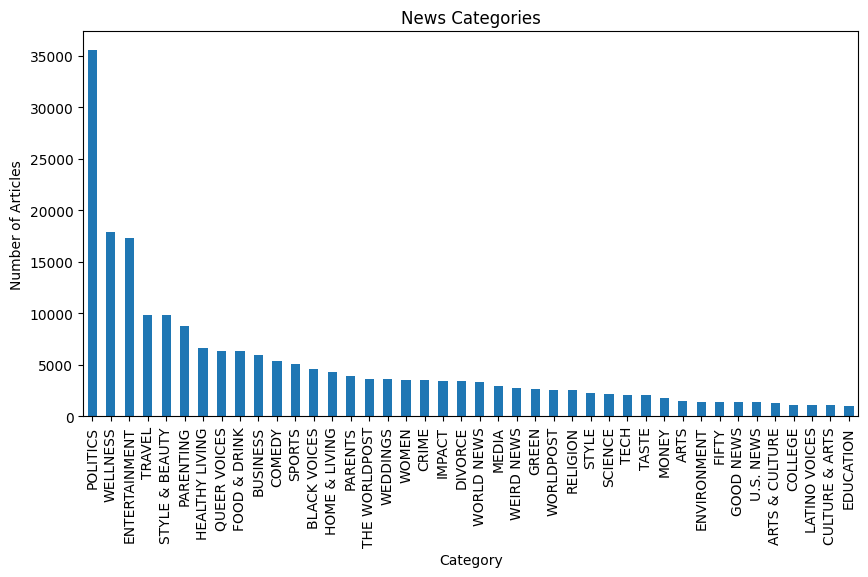

In [ ]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=90)

plt.show()

In [ ]:
df["text"] = df["headline"] + " " + df["short_description"]

In [ ]:
df = df[["category", "text"]]

df.head()

,category,text
0,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...
1,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li..."
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...
4,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...


In [ ]:
df["text"] = df["text"].str.lower()

In [ ]:
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df["text"] = df["text"].apply(clean_text)

In [ ]:
df["text"] = df["text"].str.strip()

In [ ]:
df.head()

,category,text
0,U.S. NEWS,over million americans roll up sleeves for om...
1,U.S. NEWS,american airlines flyer charged banned for lif...
2,COMEDY,of the funniest tweets about cats and dogs thi...
3,PARENTING,the funniest tweets from parents this week sep...
4,U.S. NEWS,woman who called cops on black birdwatcher los...


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
# Features (news articles)
X = df["text"]

# Labels (categories)
y = df["category"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))


Training Samples : 167611
Testing Samples  : 41903


In [ ]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])


In [ ]:
model.fit(X_train, y_train)

print("Model trained successfully!")



Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.39958952819607185


In [ ]:

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

          ARTS       0.00      0.00      0.00       310
ARTS & CULTURE       0.00      0.00      0.00       255
  BLACK VOICES       0.00      0.00      0.00       911
      BUSINESS       0.83      0.02      0.03      1176
       COLLEGE       0.00      0.00      0.00       226
        COMEDY       0.88      0.01      0.01      1044
         CRIME       0.67      0.01      0.02       725
CULTURE & ARTS       1.00      0.00      0.01       205
       DIVORCE       1.00      0.05      0.10       689
     EDUCATION       0.00      0.00      0.00       196
 ENTERTAINMENT       0.47      0.75      0.58      3499
   ENVIRONMENT       0.00      0.00      0.00       279
         FIFTY       0.00      0.00      0.00       256
  FOOD & DRINK       0.71      0.48      0.57      1290
     GOOD NEWS       0.00      0.00      0.00       260
         GREEN       0.00      0.00      0.00       536
HEALTHY LIVING       1.00      0.00      0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)


[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [ 0  0  0 ... 14  0  0]
 [ 0  0  0 ...  0  1  0]
 [ 0  0  0 ...  0  0  1]]


In [ ]:
article = [
    "The Spiderman Brand New Day movie has broken box office records worldwide, I'm very excited."
]

print(model.predict(article)[0])


ENTERTAINMENT


In [ ]:
article = [
    "The parliament passed a new education reform bill today and its applicable from the next month."
]

print(model.predict(article)[0])


POLITICS
